# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary.

#### Defining the data problem
We are tasked with using data to identify the key drivers for used car prices.
In data terms, this means training a regression model with `price` as the target, then using it to find the model's most important features.
To do this, we can:
- Clean the data, and do any data transformation needed
- Split out train/test data
- Train several regression models
- Do error analysis and cross validation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
RANDOM_STATE = 42

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

#### Data understanding - getting to know the data
1) After loading the data, use `.info()` on the dataframe to get a sense of what columns exist. There may be columns that don't seem relevant to the model (like `VIN`)
2) Use `car_data.isna().sum()` to see how many values of each column are null. For columns that have large number of null values, we should consider dropping them
3) Look at the distribution of prices, and if there are prices that don't make sense (eg very low or $0, or very high) then they are likely errors and we should consider dropping them
4) To get a better sense of the column types and range of values in categorical columns that will need to be encoded, run `.value_counts()` or `unique()` on them. If they have too many values, it might make sense to drop those columns, or encode them as a value instead of using one hot encoding
5) Create some visualizations to help get a sense of the distributions and correlations of some intuitively important features

In [2]:
car_data = pd.read_csv('data/vehicles.csv')

In [3]:
car_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [4]:
car_data.isna().sum()

id                   0
region               0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
VIN             161042
drive           130567
size            306361
type             92858
paint_color     130203
state                0
dtype: int64

In [5]:
car_data['price'].describe()

count         426,880.00
mean           75,199.03
std        12,182,282.17
min                 0.00
25%             5,900.00
50%            13,950.00
75%            26,485.75
max     3,736,928,711.00
Name: price, dtype: float64

In [6]:
car_data['condition'].value_counts()

condition
good         121456
excellent    101467
like new      21178
fair           6769
new            1305
salvage         601
Name: count, dtype: int64

In [7]:
car_data['fuel'].value_counts()

fuel
gas         356209
other        30728
diesel       30062
hybrid        5170
electric      1698
Name: count, dtype: int64

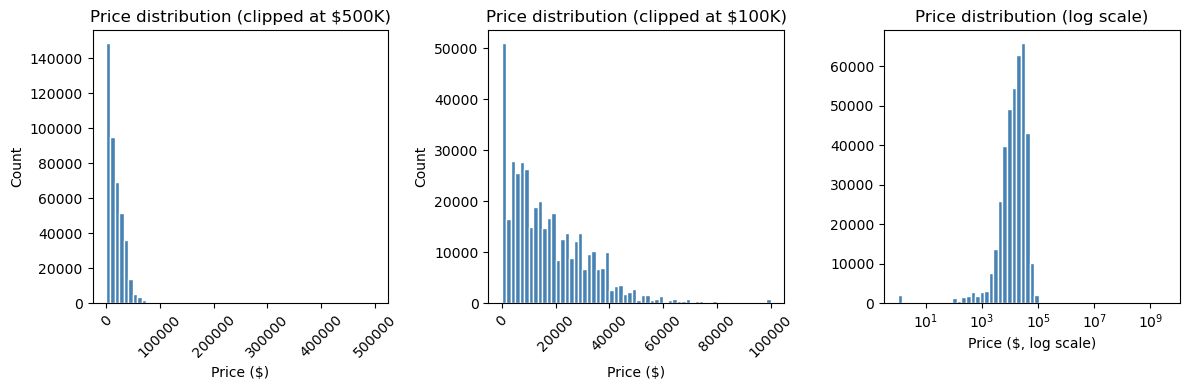

In [8]:
# Price distribution using linear and log values
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# The raw distribution is heavily right-skewed, so clip to $500k to more clearly see the distribution
axes[0].hist(car_data['price'].clip(upper=500_000), bins=60,
             color='steelblue', edgecolor='white')
axes[0].set_title('Price distribution (clipped at $500K)')
axes[0].set_xlabel('Price ($)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('Count')

# Majority of cars are under $100k, so clip there for clearer view
axes[1].hist(car_data['price'].clip(upper=100_000), bins=60,
             color='steelblue', edgecolor='white')
axes[1].set_title('Price distribution (clipped at $100K)')
axes[1].set_xlabel('Price ($)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('Count')

# use a log scale to help normalize the distribution and make it easier to see
log_prices = car_data.loc[car_data['price'] > 0, 'price']
log_bins = np.logspace(np.log10(1), np.log10(log_prices.max()), 60)
axes[2].hist(log_prices, bins=log_bins, color='steelblue', edgecolor='white')
axes[2].set_xscale('log')
axes[2].set_title('Price distribution (log scale)')
axes[2].set_xlabel('Price ($, log scale)')

plt.tight_layout()
plt.show()

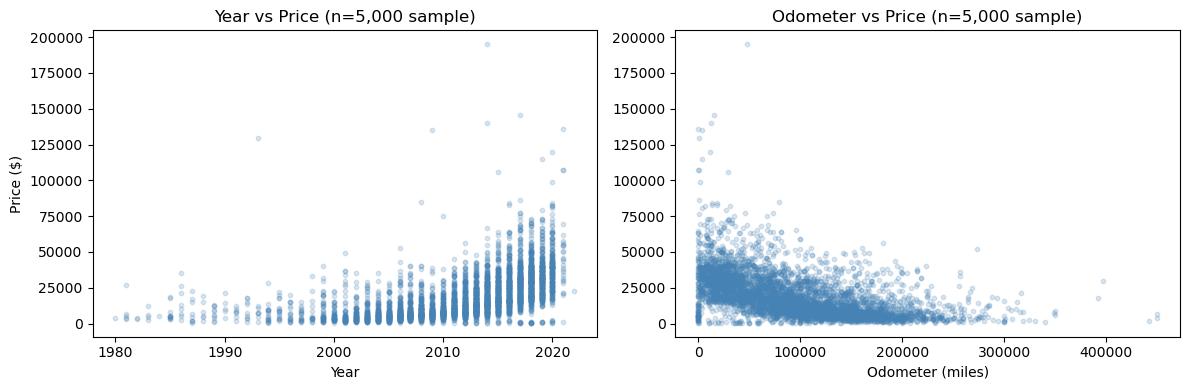

In [9]:
# Numeric features vs price. Sample down for readability — 5K should be enough to see a trend
plot_df = car_data[
    car_data['price'].between(500, 200_000)
    & car_data['year'].between(1980, 2026)
    & car_data['odometer'].between(0, 500_000)
]
sample = plot_df.sample(n=min(5000, len(plot_df)), random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(sample['year'], sample['price'], alpha=0.2, s=10, color='steelblue')
axes[0].set_title(f'Year vs Price (n={len(sample):,} sample)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Price ($)')

axes[1].scatter(sample['odometer'], sample['price'], alpha=0.2, s=10, color='steelblue')
axes[1].set_title(f'Odometer vs Price (n={len(sample):,} sample)')
axes[1].set_xlabel('Odometer (miles)')
plt.tight_layout()
plt.show()

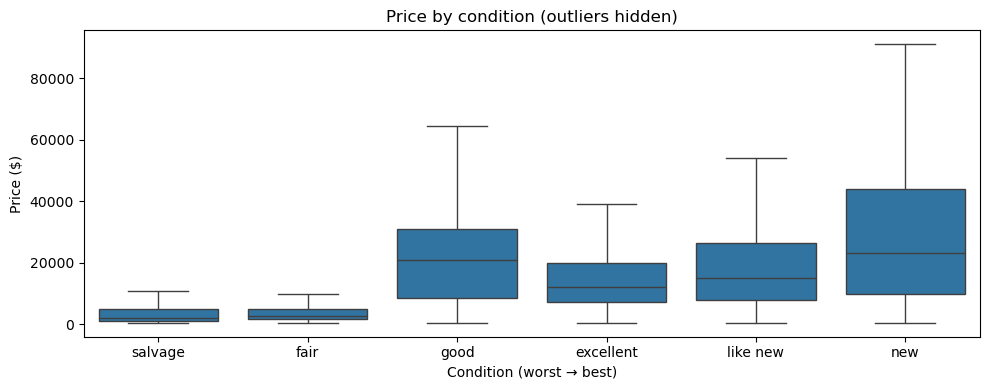

In [10]:
# Price by condition. Condition is ordinal — order the boxes from worst to best
condition_order = ['salvage', 'fair', 'good', 'excellent', 'like new', 'new']
filt = car_data[
    car_data['price'].between(500, 200_000) & car_data['condition'].notna()
]

fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=filt, x='condition', y='price', order=condition_order,
            showfliers=False, ax=ax)
ax.set_title('Price by condition (outliers hidden)')
ax.set_xlabel('Condition (worst → best)')
ax.set_ylabel('Price ($)')
plt.tight_layout()
plt.show()

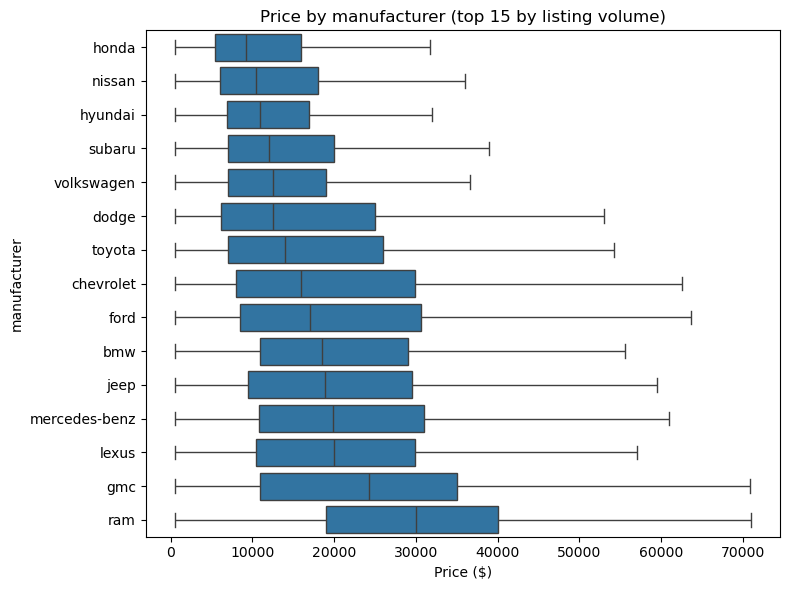

In [11]:
# Price range manufacturer (just use top 15 by frequency in dataset so it's easier to see)
# filter out prices outside of the main range to avoid skew
# We may want to use the mean price in lieu of manufacturer category to avoid too many features
filt = car_data[
    car_data['price'].between(500, 200_000) & car_data['manufacturer'].notna()
]
top15 = filt['manufacturer'].value_counts().head(15).index
top15_data = filt[filt['manufacturer'].isin(top15)]

# order rows bottom to top by mediam price so we can see cheapest --> most expensive
order = (
    top15_data.groupby('manufacturer')['price']
    .median()
    .sort_values()
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=top15_data, y='manufacturer', x='price', order=order, showfliers=False, ax=ax)
ax.set_title('Price by manufacturer (top 15 by listing volume)')
ax.set_xlabel('Price ($)')
plt.tight_layout()
plt.show()

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`.

Strategy:
1. Filter out `price`, `year`, `odometer` values that don't make sense
2. Drop columns that are identifiers (`id`, `VIN`), too-high cardinality (`model`, `region`), or too sparse (`size`, `paint_color`, `state`).
3. Drop rows where information that feels very important to car price (manufacturer, year, odometer) are null, since there are relatively low numbers of rows with null values in those columns
3. Fill remaining nulls (median for numeric, mode/'unknown' for categorical).
4. Engineer `vehicle_age` (more meaningful than raw year for a linear model)
5. Ordinal-encode `condition` (it has a natural order)
6. One-hot encode the rest of the categoricals **except** `manufacturer` (since there's too many manufacturers)
7. Train/test split
8. Target-encode `manufacturer` using only training data (avoids leaking test data into values)
9. Standard-scale features (Lasso/Ridge are sensitive to feature scale)

In [12]:
# make a copy so we can look at the original data if needed
df = car_data.copy()

# 1. Filter out nonsensical or extreme values
# prices below $200 or above $800,000 are likely errors or extreme outliers that will skew analysis
df = df[df['price'].between(200, 800_000)]
# there's unlikely to be cars older than 1900, and there's none that are from the future
df = df[df['year'].between(1900, 2026) | df['year'].isna()]
# for the odometer, it can't be negative, and unlikely any cars run over 500k miles
df = df[df['odometer'].between(0, 500_000) | df['odometer'].isna()]

# 2. Drop columns that won't help
df = df.drop(columns=['id', 'VIN', 'model', 'region', 'size', 'paint_color', 'state'])

# Drop rows missing manufacturer and year - feel very important to price, and it's hard to backfill with a guess
df = df.dropna(subset=['manufacturer', 'year', 'odometer'])

# 3. Fill remaining nulls.
df['drive'] = df['drive'].fillna('unknown')
df['type'] = df['type'].fillna('other')
for col in ['fuel', 'title_status', 'transmission', 'condition', 'cylinders']:
    df[col] = df[col].fillna(df[col].mode()[0])

print(f'Shape after cleaning: {df.shape}')
df.isna().sum().sum(), 'nulls remaining'

Shape after cleaning: (370430, 11)


(np.int64(0), 'nulls remaining')

In [13]:
# 4. Tranform the data - vehicle age replaces raw year
df['vehicle_age'] = 2026 - df['year']
df = df.drop(columns=['year'])

# 5. Ordinal-encode condition
condition_order = {'salvage': 0, 'fair': 1, 'good': 2, 'excellent': 3, 'like new': 4, 'new': 5}
df['condition'] = df['condition'].map(condition_order)

# 6. One-hot encode the rest (except manufacturer — we'll target-encode that after the split)
categorical_cols = ['drive', 'type', 'fuel', 'title_status', 'transmission', 'cylinders']
# find the mode, and use it as the reference column (what the other features will be in relation to)
references_to_drop = [
    f'{col}_{df[col].mode()[0]}' for col in categorical_cols
]
print(f' Reference columns for one-hot encoded features: {references_to_drop}')
df_enc = pd.get_dummies(df, columns=categorical_cols)
df_enc = df_enc.drop(columns=references_to_drop)
print(f'Shape after encoding: {df_enc.shape}')

 Reference columns for one-hot encoded features: ['drive_4wd', 'type_other', 'fuel_gas', 'title_status_clean', 'transmission_automatic', 'cylinders_6 cylinders']
Shape after encoding: (370430, 38)


In [14]:
# 7. Train/test split (before target encoding, so we don't leak data from the test set)
X = df_enc.drop(columns=['price'])
y = df_enc['price']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# 8. Target-encode manufacturer using training data only
mfr_map = y_train.groupby(X_train['manufacturer']).mean()
global_mean_price = y_train.mean()

X_train = X_train.copy()
X_test = X_test.copy()
X_train['manufacturer_enc'] = X_train['manufacturer'].map(mfr_map)
X_test['manufacturer_enc'] = X_test['manufacturer'].map(mfr_map).fillna(global_mean_price)

X_train = X_train.drop(columns=['manufacturer']).astype(float)
X_test = X_test.drop(columns=['manufacturer']).astype(float)

# 9. Scale to better normalize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train shape: {X_train_scaled.shape} | Test shape: {X_test_scaled.shape}')

Train shape: (296344, 37) | Test shape: (74086, 37)


### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

**Note**: I chose to put modeling and evaluation together, because it was easier to think about iterating on it in that way

In [15]:
# We will train on 3 regression models - linear, Lasso, and Ridge
# for Lasso and Ridge, pick a reasonable alpha to start, we will use GridSearch later to tune it
models = {
    'Linear': LinearRegression(),
    'Lasso':  Lasso(alpha=10.0, max_iter=10_000),
    'Ridge':  Ridge(alpha=1.0),
}

In [16]:
# Create some helper methods to evaluate
# simple error analysis
def score_predictions(y_actual, y_pred):
    """Return MSE, RMSE, MAE, R² for a single set of predictions."""
    mse = mean_squared_error(y_actual, y_pred)
    return {
        'MSE':  mse,
        'RMSE': np.sqrt(mse),
        'MAE':  mean_absolute_error(y_actual, y_pred),
        'R2':   r2_score(y_actual, y_pred),
    }

# cross validation
def cross_val_metrics(model, X, y, cv):
    """Average MSE/RMSE/MAE/R² across CV folds."""
    neg_mse = cross_val_score(model, X, y, cv=cv, scoring='neg_mean_squared_error', n_jobs=-1)
    neg_mae = cross_val_score(model, X, y, cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)
    r2      = cross_val_score(model, X, y, cv=cv, scoring='r2', n_jobs=-1)
    mse = -neg_mse.mean()
    return {
        'MSE':  mse,
        'RMSE': np.sqrt(mse),
        'MAE':  -neg_mae.mean(),
        'R2':   r2.mean(),
    }

In [17]:
# do an initial fit and eval for each model
initial_metrics = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    metrics = score_predictions(y_test, model.predict(X_test_scaled))
    initial_metrics.append({'model': name, **metrics})

initial_metrics_df = pd.DataFrame(initial_metrics).set_index('model')
initial_metrics_df

,MSE,RMSE,MAE,R2
model,,,,
Linear,"101,612,966.96","10,080.33","6,558.55",0.55
Lasso,"101,621,751.72","10,080.76","6,557.03",0.55
Ridge,"101,612,963.88","10,080.33","6,558.55",0.55


In [18]:
# Do K Fold cross validation (with 5 splits) to run the models on different cuts of the data
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

kfold_rows = []
for name, model in models.items():
    metrics = cross_val_metrics(model, X_train_scaled, y_train, cv=kf)
    kfold_rows.append({'model': name, **metrics})

kfold_df = pd.DataFrame(kfold_rows).set_index('model')
kfold_df

,MSE,RMSE,MAE,R2
model,,,,
Linear,"105,227,829.76","10,258.06","6,551.66",0.54
Lasso,"105,231,295.35","10,258.23","6,550.14",0.54
Ridge,"105,227,829.51","10,258.06","6,551.66",0.54


In [19]:
# Run grid search on the Ridge model to find the best alpha
ridge_grid = GridSearchCV(
    estimator=Ridge(),
    param_grid={'alpha': [0.01, 0.1, 1, 10, 100, 1_000]},
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1,
)
ridge_grid.fit(X_train_scaled, y_train)

print(f"Best Ridge alpha: {ridge_grid.best_params_['alpha']}")
print(f"Best CV MSE:     {-ridge_grid.best_score_:,.0f}")

tuned_ridge_metrics = score_predictions(y_test, ridge_grid.best_estimator_.predict(X_test_scaled))
pd.DataFrame([{'model': 'Ridge (tuned)', **tuned_ridge_metrics}]).set_index('model')

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Ridge alpha: 100
Best CV MSE:     105,247,060


,MSE,RMSE,MAE,R2
model,,,,
Ridge (tuned),"101,612,671.15","10,080.31","6,558.38",0.55


In [20]:
# Run Grid Search on the Lasso model to find the best alpha
lasso_grid = GridSearchCV(
    estimator=Lasso(max_iter=10_000),
    param_grid={'alpha': [0.1, 1, 10, 100, 1_000]},
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1,
)
lasso_grid.fit(X_train_scaled, y_train)

print(f"Best Lasso alpha: {lasso_grid.best_params_['alpha']}")
print(f"Best CV MSE:     {-lasso_grid.best_score_:,.0f}")

tuned_lasso_metrics = score_predictions(y_test, lasso_grid.best_estimator_.predict(X_test_scaled))
pd.DataFrame([{'model': 'Lasso (tuned)', **tuned_lasso_metrics}]).set_index('model')

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best Lasso alpha: 1
Best CV MSE:     105,247,065


,MSE,RMSE,MAE,R2
model,,,,
Lasso (tuned),"101,613,485.98","10,080.35","6,558.38",0.55


In [21]:
# Create a summary table of the results from each cross validation approach
summary = pd.concat({
    'Initial model run':   initial_metrics_df,
    '5-Fold CV':      kfold_df,
    'GridSearch CV':  pd.DataFrame(
        [{'model': 'Ridge (tuned)', **tuned_ridge_metrics},
         {'model': 'Lasso (tuned)', **tuned_lasso_metrics}]
    ).set_index('model'),
}, names=['evaluation', 'model'])
summary

MSE      RMSE      MAE   R2
evaluation        model                                               
Initial model run Linear        101,612,966.96 10,080.33 6,558.55 0.55
                  Lasso         101,621,751.72 10,080.76 6,557.03 0.55
                  Ridge         101,612,963.88 10,080.33 6,558.55 0.55
5-Fold CV         Linear        105,227,829.76 10,258.06 6,551.66 0.54
                  Lasso         105,231,295.35 10,258.23 6,550.14 0.54
                  Ridge         105,227,829.51 10,258.06 6,551.66 0.54
GridSearch CV     Ridge (tuned) 101,612,671.15 10,080.31 6,558.38 0.55
                  Lasso (tuned) 101,613,485.98 10,080.35 6,558.38 0.55

Using the models we trained, and additional feature selection tools like permutation importance, we want to identify the most important features for predicting price of the car

In [22]:
# For ridge regression, the most important features are the ones where the absolute values of the
# coefficients are higher (they are weighted more).
# If it's negative, it means it has a negative correlation with price.
# Pull the top 15 features based on the coefficient size
coefs = pd.Series(
    ridge_grid.best_estimator_.coef_,
    index=X_train.columns,
).sort_values(key=abs, ascending=False)

coefs.head(15).to_frame('ridge_coef')

,ridge_coef
odometer,"-6,747.52"
fuel_diesel,"3,308.99"
vehicle_age,"-3,259.87"
manufacturer_enc,"2,415.75"
drive_fwd,"-2,158.87"
drive_unknown,"-1,674.67"
cylinders_4 cylinders,"-1,211.22"
type_sedan,"-1,164.47"
cylinders_8 cylinders,"1,001.05"
drive_rwd,-875.41


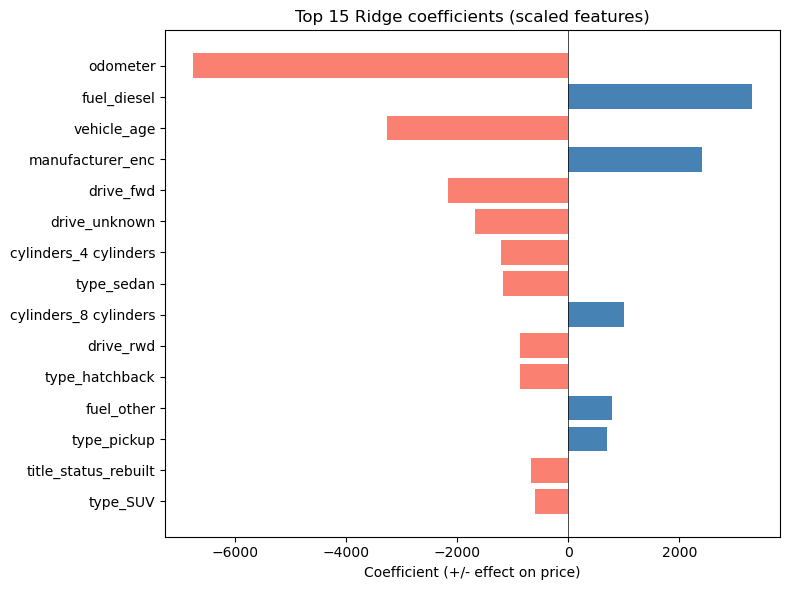

In [23]:
# Plot the coefficients so we can visually see the impact
fig, ax = plt.subplots(figsize=(8, 6))
top = coefs.head(15).iloc[::-1]
ax.barh(top.index, top.values, color=np.where(top.values > 0, 'steelblue', 'salmon'))
ax.axvline(0, color='black', linewidth=0.5)
ax.set_title('Top 15 Ridge coefficients (scaled features)')
ax.set_xlabel('Coefficient (+/- effect on price)')
plt.tight_layout()
plt.show()

In [24]:
from sklearn.inspection import permutation_importance

# Permutation importance is a feature selection tool for finding the most important features
# Run permutation importance on the tuned Ridge model, evaluated on the held-out test set, and using R^2 for scoring
perm_result = permutation_importance(
    ridge_grid.best_estimator_,
    X_test_scaled,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scoring='r2',
)

perm_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance_mean': perm_result.importances_mean,
    'importance_std':  perm_result.importances_std,
}).sort_values('importance_mean', ascending=False).reset_index(drop=True)

perm_importance.head(15)

,feature,importance_mean,importance_std
0,odometer,0.41,0.00
1,fuel_diesel,0.10,0.00
2,vehicle_age,0.09,0.00
3,manufacturer_enc,0.05,0.00
4,drive_fwd,0.04,0.00
5,drive_unknown,0.02,0.00
6,cylinders_4 cylinders,0.01,0.00
7,type_sedan,0.01,0.00
8,cylinders_8 cylinders,0.01,0.00
9,drive_rwd,0.01,0.00


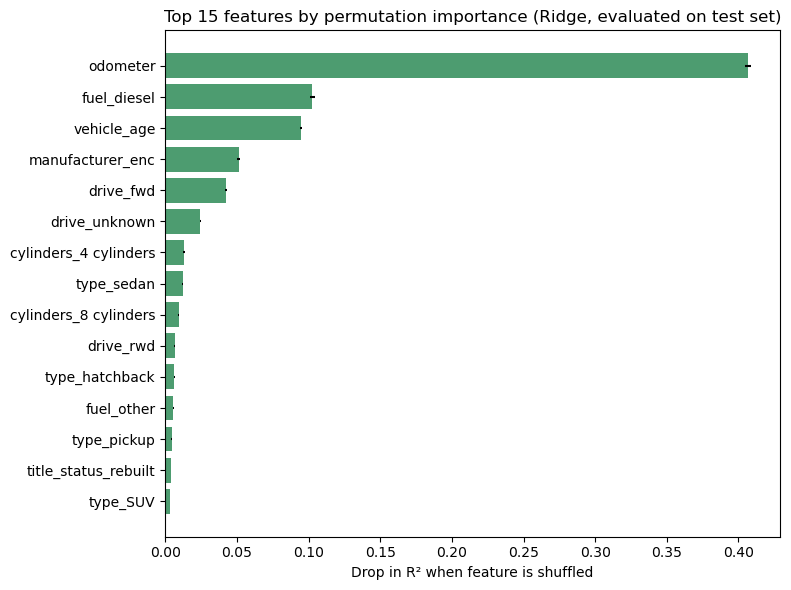

In [25]:
# Plot the importance based on permutation importance analysis
fig, ax = plt.subplots(figsize=(8, 6))
top = perm_importance.head(15).iloc[::-1]
ax.barh(top['feature'], top['importance_mean'],
        xerr=top['importance_std'], color='seagreen', alpha=0.85)
ax.set_title('Top 15 features by permutation importance (Ridge, evaluated on test set)')
ax.set_xlabel('Drop in R² when feature is shuffled')
plt.tight_layout()
plt.show()

In [26]:
# In Lasso regressions, the less important features get a coefficient of 0, so find the features that have non-0 coefficients
lasso_coefs = pd.Series(
    lasso_grid.best_estimator_.coef_,
    index=X_train.columns,
).sort_values(key=abs, ascending=False)

n_total = len(lasso_coefs)
n_zero = (lasso_coefs == 0).sum()
n_kept = n_total - n_zero
best_alpha = lasso_grid.best_params_['alpha']
print(f"Lasso (alpha={best_alpha}) kept {n_kept}/{n_total} features, zeroed {n_zero}.")

zeroed = sorted(lasso_coefs[lasso_coefs == 0].index.tolist())
print("\nFeatures Lasso dropped to zero:")
for f in zeroed:
    print(f"  - {f}")

print("\nFeatures Lasso kept (ranked by abs value of coefficient):")
lasso_coefs[lasso_coefs != 0].to_frame('lasso_coef')

Lasso (alpha=1) kept 37/37 features, zeroed 0.

Features Lasso dropped to zero:

Features Lasso kept (ranked by abs value of coefficient):


,lasso_coef
odometer,"-6,749.64"
fuel_diesel,"3,309.64"
vehicle_age,"-3,259.51"
manufacturer_enc,"2,416.32"
drive_fwd,"-2,158.06"
drive_unknown,"-1,673.08"
cylinders_4 cylinders,"-1,211.03"
type_sedan,"-1,163.89"
cylinders_8 cylinders,"1,000.75"
drive_rwd,-873.08


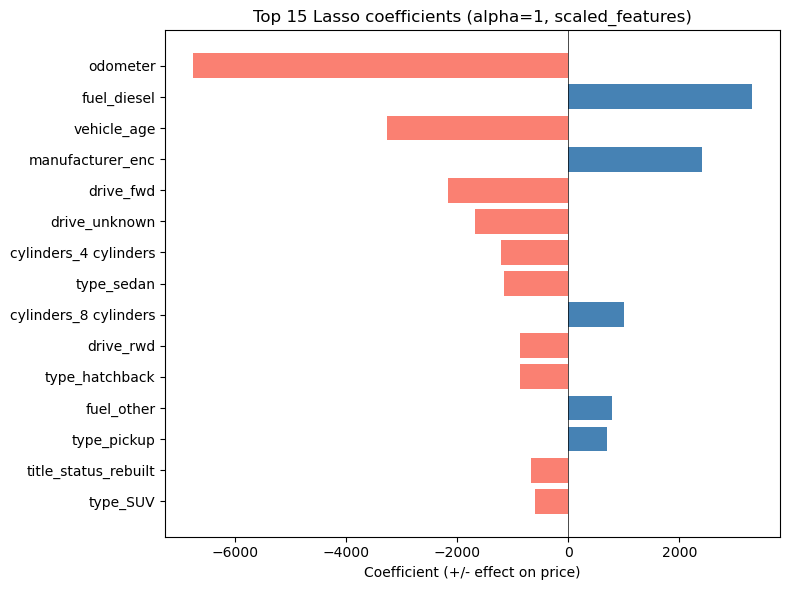

In [27]:
# Plot the coefficients for lasso
top_lasso = lasso_coefs[lasso_coefs != 0].head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_lasso.index, top_lasso.values, color=np.where(top_lasso.values > 0, 'steelblue', 'salmon'))
ax.axvline(0, color='black', linewidth=0.5)
ax.set_title(f'Top 15 Lasso coefficients (alpha={lasso_grid.best_params_['alpha']}, scaled_features)')
ax.set_xlabel('Coefficient (+/- effect on price)')
plt.tight_layout()
plt.show()

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

Dear dealership team,

I used several data analysis techniques on used car data to help determine what features are most important when predicting the price of a car.
My conclusion was that the most important features for car price are (by order of importance):
- Odometer - cars with higher mileage sell for lower prices
- Fuel - diesel cars sell for significantly higher prices than gas cars. Hybrid and electric cars have a smaller price increase compared to gas.
- Vehicle age - older cars sell for lower prices than newer cars
- Manufacturer - as expected, car brand can impact the price, even when accounting for other factors like mileage age, etc. Specifically, brands like Ram, GMC, Lexus, and Mercedes Benz sell for higher prices. Brands like Honda, Nissan, and Hyundai sell for lower.
- Drive - cars that have all wheel drive have higher prices. The price based on drive is awd > rwd > fwd
- Cylinders - the most common used cars sold have 6 cylinders, and more cylinders tended to have a higher price (less cylinderes had lower price)
- Type - many of the cars in the dataset had type other, which made it a bit harder to conclude about. However, the data showed that pickup trucks were generally sold for higher prices, then SUVs, hatchbacks, then sedan

In relation to fine tuning your inventory, a few things are important to note about this conclusion:
- All of these factors interact to impact the price of the car. For example, a car with high mileage might still sell for more than a car with lower mileage if it has all wheel drive, more cylinders, is a pickup, etc
- If you want to be able to sell to people with different financial needs, I'd suggest getting a range of brands. More luxury car brands can sell for higher prices, but might be prohibitive for people looking for a more affordable car. When acquiring cheaper brands (like Honda), look for cars that have other feartures that can drive up the price - like low mileage, more recent years, and all wheel drive.
- Now that the model is built, you can also use it to set prices by using the model to predict the price a car would sell for given it's specific attributes. This model is a predicted price based on historical data, so won't account for market trends or individual buyer behavior, but could give you a sense of what people have been willing to pay for similar cars, taking into account multiple factors.

